In [ ]:
pip install pycalphad

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.1/6.1 MB 25.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 MB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 307.5/307.5 kB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 257.1/257.1 kB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.1/109.1 kB 6.1 MB/s eta 0:00:00


Gibbs Free Energy Sympy Expression Code

This code block extracts and manipulates the Gibbs free energy expression from a tdb file for a specific phase and evaluates the Gibbs expression at a specific temperature.

In [ ]:
from pycalphad import Database, Model
import sympy as sp

# Load database and define system
db = Database('SiC-91Lac.tdb')
# Add 'VA' to components as it's required for some phase models in pycalphad
components = ['SI','C','VA']
phase_name = 'SIC_B3'

# Build the pycalphad model
model = Model(db, components, phase_name)

# Extract the SymPy expression for Gibbs free energy (GM)
# 'model.energy' holds the SymPy expression object
gibbs_expr = model.energy
print("SymPy Expression (full):", gibbs_expr)

# --- New code to evaluate at a specific temperature, keeping site fractions symbolic ---
print("\n--- Evaluating Gibbs Free Energy Expression at a Specific Temperature ---")
# Define a specific temperature for evaluation
temp_val = 1000.0 # Kelvin

# Substitute only the temperature variable T with the numerical value
gibbs_expr_at_temp = gibbs_expr.subs(T, temp_val)

print(f"Gibbs Free Energy Expression at T = {temp_val} K:\n{gibbs_expr_at_temp}")


SymPy Expression (full): 8.3145*T*(1.0*Piecewise((SIC_B30SI*log(SIC_B30SI), 1e-15 < SIC_B30SI), (0, True)) + 1.0*Piecewise((SIC_B31C*log(SIC_B31C), 1e-15 < SIC_B31C), (0, True)))/(1.0*SIC_B30SI + 1.0*SIC_B31C) + SIC_B30SI*Piecewise((-85572.264 + 173.2005*T - 25.856*T*log(T) + 438415.0*T**(-1.0) - 0.02107*T**2.0 + 3.2153e-06*T**3.0, T < 700.0), (-95145.902 + 300.346*T - 45.093*T*log(T) + 1341065.0*T**(-1.0) - 0.00367*T**2.0 + 2.2e-07*T**3.0, And(T < 2100.0, 700.0 <= T)), (-105007.971 + 360.309*T - 53.073*T*log(T) + 3693345.0*T**(-1.0) - 0.00074525*T**2.0 + 1.73167e-08*T**3.0, 2100.0 <= T), (0, True))*SIC_B31C/(1.0*SIC_B30SI + 1.0*SIC_B31C)
Derived Entropy Expression: -(8.3145*(1.0*Piecewise((SIC_B30SI*log(SIC_B30SI), 1e-15 < SIC_B30SI), (0, True)) + 1.0*Piecewise((SIC_B31C*log(SIC_B31C), 1e-15 < SIC_B31C), (0, True)))/(1.0*SIC_B30SI + 1.0*SIC_B31C) + 8.3145*T*(1.0*Piecewise((0, 1e-15 < SIC_B30SI), (0, True)) + 1.0*Piecewise((0, 1e-15 < SIC_B31C), (0, True)))/(1.0*SIC_B30SI + 1.0*SIC_B31

Excess Gibbs Free Energy Sympy Expression Code

This code calculates the excess Gibbs Free Energy for a particular phase using a tdb file by subtracting the ideal mixing term from the total molar Gibbs energy.

In [ ]:
import sympy as sp
from pycalphad import Database, Model
import pycalphad.variables as v

# ==========================================
# 1. Parse the TDB File and Extract the Phase Model
# ==========================================
# Load your local file (e.g., 'Al-Zn.tdb')
# For illustration, we assume a binary system of components: COMP1 and COMP2
db = Database('SiC-91Lac.tdb')
# FIX: Changed components to match the Fe-C database
components = ['SI','C','VA']
phase_name = 'SIC_B3'

# Create a pycalphad Model object.
# This automatically extracts and builds the symbolic Gibbs energy for the phase.
mod = Model(db, components, phase_name)

# ==========================================
# 2. Extract the Raw SymPy Expression
# ==========================================
# mod.GM contains the total molar Gibbs energy of the phase as a pure SymPy expression!
G_mix_sympy = mod.GM

print("Raw G_mix from TDB:")
print(G_mix_sympy)

# ==========================================
# 3. Align SymPy Variables
# ==========================================
# Let's map pycalphad's variables to clean x1, x2, T variables if desired
x1, x2, T = sp.symbols('x1 x2 T', real=True, positive=True)
R = sp.symbols('R', real=True, positive=True) # pycalphad usually hardcodes R as 8.31451

# Substitute to standard variable naming convention
# FIX: Updated v.X mappings to 'FE' and 'C'
G_mix_standardized = G_mix_sympy.subs({
    v.T: T,
    v.X('Si'): x1,
    v.X('C'): x2
})

# ==========================================
# 4. Apply Your Symbolic Excess Calculation Template
# ==========================================
# Define standard ideal mixing term
G_ideal = R * T * (x1 * sp.log(x1) + x2 * sp.log(x2))

# Calculate Excess Gibbs Free Energy purely symbol-to-symbol
G_excess = G_mix_standardized - G_ideal

# ==========================================
# 5. Simplify or Display
# ==========================================
# Simplification can take a moment if the TDB expression is large (Redlich-Kister polynomial)
print("\nFinal G_excess Expression from TDB:")
print(G_excess.simplify())

Raw G_mix from TDB:
8.3145*T*(1.0*Piecewise((SIC_B30SI*log(SIC_B30SI), 1e-15 < SIC_B30SI), (0, True)) + 1.0*Piecewise((SIC_B31C*log(SIC_B31C), 1e-15 < SIC_B31C), (0, True)))/(1.0*SIC_B30SI + 1.0*SIC_B31C) + SIC_B30SI*Piecewise((-85572.264 + 173.2005*T - 25.856*T*log(T) + 438415.0*T**(-1.0) - 0.02107*T**2.0 + 3.2153e-06*T**3.0, T < 700.0), (-95145.902 + 300.346*T - 45.093*T*log(T) + 1341065.0*T**(-1.0) - 0.00367*T**2.0 + 2.2e-07*T**3.0, And(T < 2100.0, 700.0 <= T)), (-105007.971 + 360.309*T - 53.073*T*log(T) + 3693345.0*T**(-1.0) - 0.00074525*T**2.0 + 1.73167e-08*T**3.0, 2100.0 <= T), (0, True))*SIC_B31C/(1.0*SIC_B30SI + 1.0*SIC_B31C)

Final G_excess Expression from TDB:
Piecewise((T**(-1.0)*(T**2.0*(8.3145*Y(SIC_B3,0,SI)*log(Y(SIC_B3,0,SI)) + 8.3145*Y(SIC_B3,1,C)*log(Y(SIC_B3,1,C)) - 1.0*R*(x1*log(x1) + x2*log(x2))*(Y(SIC_B3,0,SI) + Y(SIC_B3,1,C))) - 1.0*Y(SIC_B3,0,SI)*(-438415.0 + T**1.0*(85572.264 - 173.2005*T + 25.856*T*log(T) + 0.02107*T**2.0 - 3.2153e-06*T**3.0))*Y(SIC_B3,1,C))/(Y

Iron-Carbon Phase Diagram Code

This code plots a binary phase diagram using the 'binplot' function from pycalphad, visualizing the stable phases across a range of compositions for 1 element (in this case, carbon) and different temperatures.

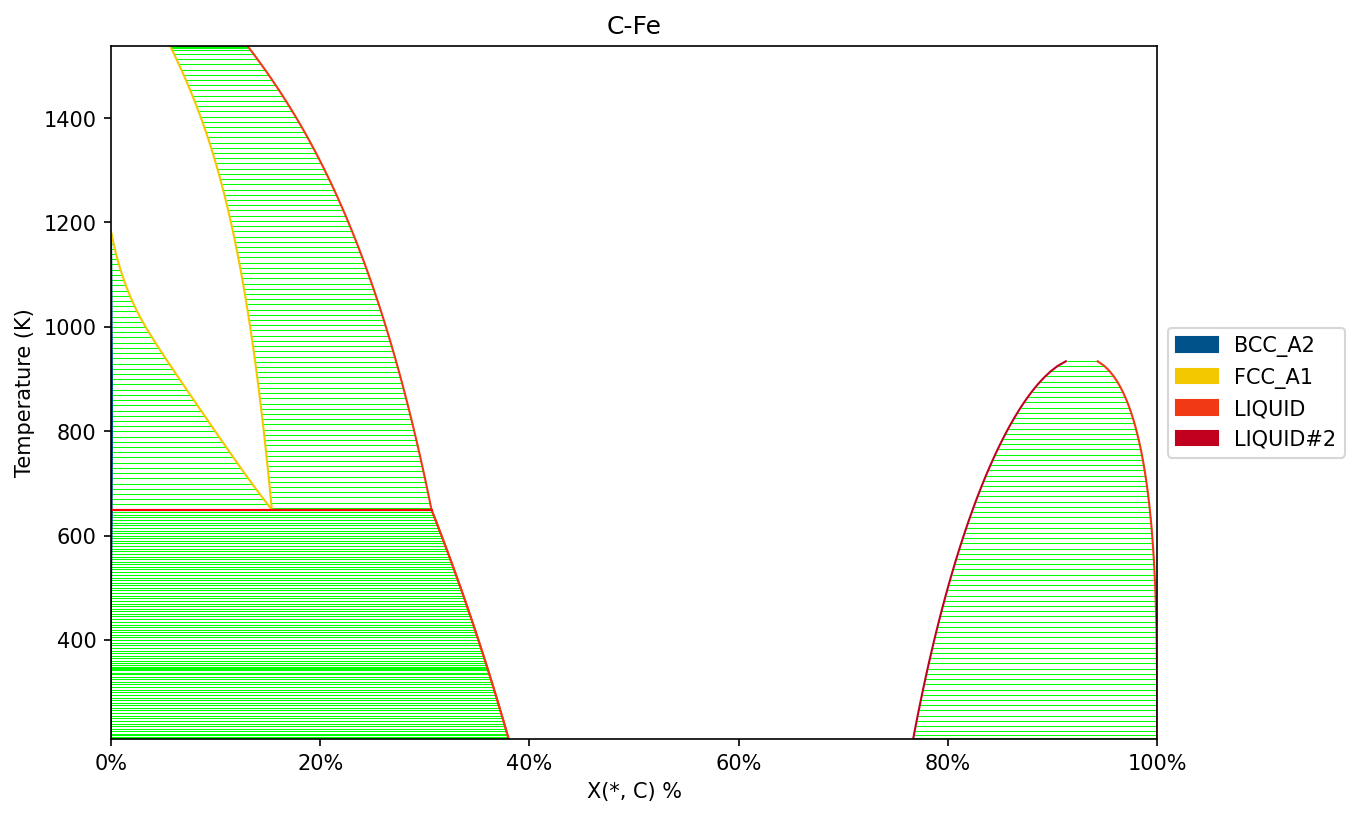

In [ ]:
import matplotlib.pyplot as plt
from pycalphad import Database, binplot
import pycalphad.variables as v
from matplotlib.ticker import PercentFormatter # Import PercentFormatter

# Load database and choose the phases that will be considered
db = Database('FeC-24Eno.tdb')
components = ['FE', 'C', 'VA']
my_phases = ['LIQUID', 'BCC_A2', 'FCC_A1']
# The x-axis is already set to go up to 0.65 (65%) carbon content
conditions = {v.X('C'):(0,1,0.01), v.T: (210, 1538, 10), v.P:101325, v.N: 1}

# Create a matplotlib Figure object and get the active Axes
fig = plt.figure(figsize=(9,6),dpi=150)
axes = fig.gca() # Get current axes

# Compute the phase diagram and plot it on the existing axes using the `plot_kwargs={'ax': axes}` keyword argument
binplot(db, components, my_phases, conditions, plot_kwargs=dict(ax=axes))

# Apply PercentFormatter to the x-axis
axes.xaxis.set_major_formatter(PercentFormatter(xmax=1.0)) # xmax=1.0 because the data is 0-1 fraction
axes.set_xlabel('X(*, C) %') # Update x-axis label for clarity

plt.show()

Iron-Carbon Gibbs Free Energy Curves with Common Tangent Code

This code calculates and plots the common tangent construction for two coexisting phases for a binary system at a specific temperature. It visualizes the Gibbs free energy curves for each phase and indentifies the equilibrium compositions where a common tangent can be drawn.

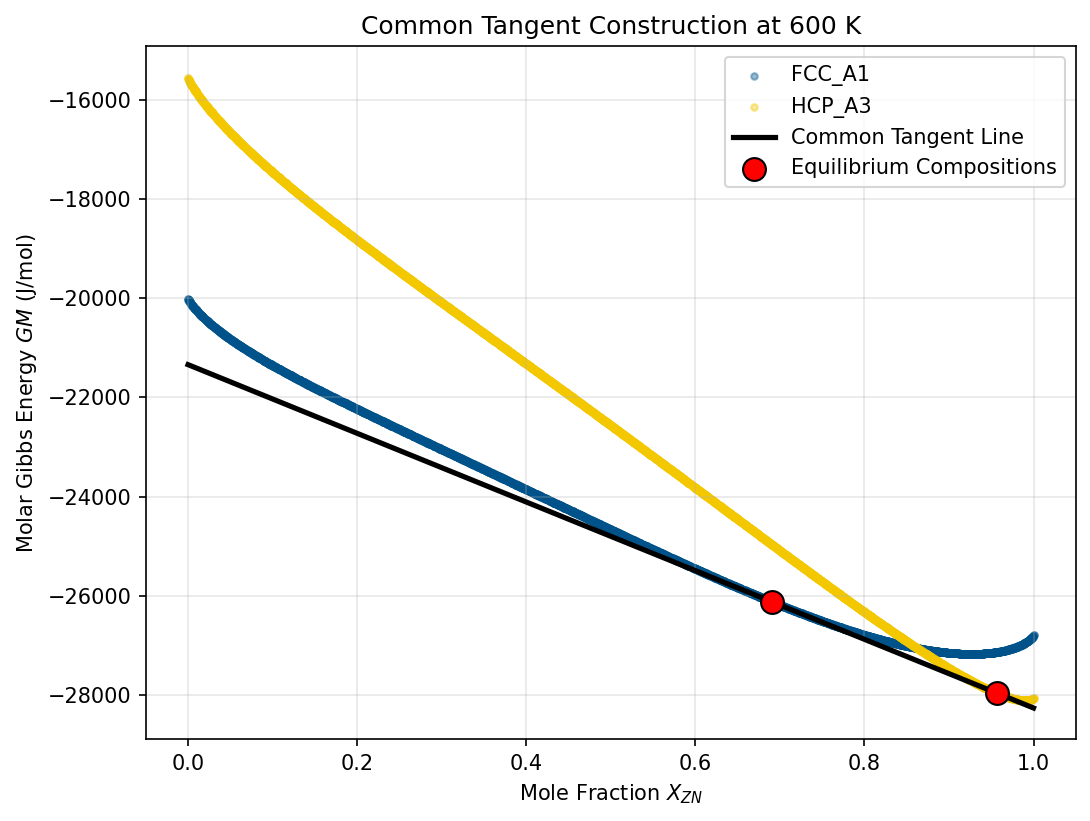

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pycalphad import Database, calculate, equilibrium
from pycalphad.plot.utils import phase_legend # Corrected import path for phase_legend
import pycalphad.variables as v # Import pycalphad.variables

# 1. Setup system parameters
dbf = Database('AlZn-86Mey.tdb')  # Replace with your TDB file path
components = ['AL', 'ZN', 'VA']
phases = ['FCC_A1', 'HCP_A3']  # The two coexisting phases
temp = 600                     # Temperature in Kelvin

# 2. Compute full Gibbs curves for background visualization
legend_colors = phase_legend(phases)
fig, ax = plt.subplots(figsize=(8, 6), dpi=150)

for phase_name in phases:
    res = calculate(dbf, components, phase_name, T=temp, P=101325, output='GM')
    ax.scatter(res.X.sel(component='ZN'), res.GM,
               c=legend_colors[1][phase_name], label=phase_name, s=10, alpha=0.4) # FIX: Access color dictionary using legend_colors[1]

# 3. Run a composition sweep to locate the two-phase region safely
# FIX: Create a conditions dictionary and pass it to equilibrium
conditions = {
    v.T: temp,
    v.P: 101325,
    v.X('ZN'): np.linspace(0.01, 0.99, 50)
}
eq_res = equilibrium(dbf, components, phases, conditions=conditions)

# Squeeze out the constant P and T axes to get 2D matrices (X_sweep_steps, vertex)
phase_matrix = eq_res.Phase.values.squeeze()
x_phase_matrix = eq_res.X.sel(component='ZN').values.squeeze()

# 4. Find an index along the composition sweep where BOTH phases stably coexist
two_phase_idx = None
for i in range(len(phase_matrix)):
    active_phases = [p for p in phase_matrix[i] if p != '']
    if len(set(active_phases)) == 2:
        two_phase_idx = i
        break

if two_phase_idx is None:
    raise ValueError("Two-phase region not found. Adjust temperature or check phase names.")

# 5. Extract the exact tie-line endpoints and chemical potentials at that index
coexisting_phases = phase_matrix[two_phase_idx]
coexisting_comps = x_phase_matrix[two_phase_idx]

# Map the compositions correctly to the respective phases array order
tangent_xs = []
for phase_name in phases:
    idx = np.where(coexisting_phases == phase_name)[0][0]
    tangent_xs.append(coexisting_comps[idx])
tangent_xs = np.array(tangent_xs)

# Get corresponding chemical potentials to define the exact line height
mu_al = float(eq_res.MU.sel(component='AL').values.squeeze()[two_phase_idx])
mu_zn = float(eq_res.MU.sel(component='ZN').values.squeeze()[two_phase_idx])

# Calculate exact contact heights using the tangent relation: G = (1-X)*mu_AL + X*mu_ZN
tangent_ys = (1 - tangent_xs) * mu_al + tangent_xs * mu_zn

# 6. Plot the precise point-to-point common tangent line
# Extend the common tangent line for visualization
x_vals_extended = np.linspace(0, 1, 100) # Extended range for plotting
extended_tangent_ys = (1 - x_vals_extended) * mu_al + x_vals_extended * mu_zn
ax.plot(x_vals_extended, extended_tangent_ys, color='black', linestyle='-', linewidth=2.5,
        label='Common Tangent Line')

# Place red touchpoints exactly at the intersection coordinates
ax.scatter(tangent_xs, tangent_ys, color='red', marker='o', s=120, edgecolors='black',
           zorder=5, label='Equilibrium Compositions')

# Formatting
ax.set_xlabel('Mole Fraction $X_{ZN}$')
ax.set_ylabel('Molar Gibbs Energy $GM$ (J/mol)')
ax.set_title(f'Common Tangent Construction at {temp} K')
ax.legend()
plt.grid(True, alpha=0.3)
plt.show()